In [1]:
import zipfile, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
uploaded = files.upload()
zip_file_name = list(uploaded.keys())[0]
extract_path = "/content/data"
with zipfile.ZipFile(zip_file_name, "r") as z:
    z.extractall(extract_path)
csv_file = None
for root, _, fnames in os.walk(extract_path):
    for f in fnames:
        if f.endswith(".csv"):
            csv_file = os.path.join(root, f); break
df = pd.read_csv(csv_file, low_memory=False)
print(f"Shape: {df.shape}")
df.head()

Saving archive.zip to archive.zip
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02


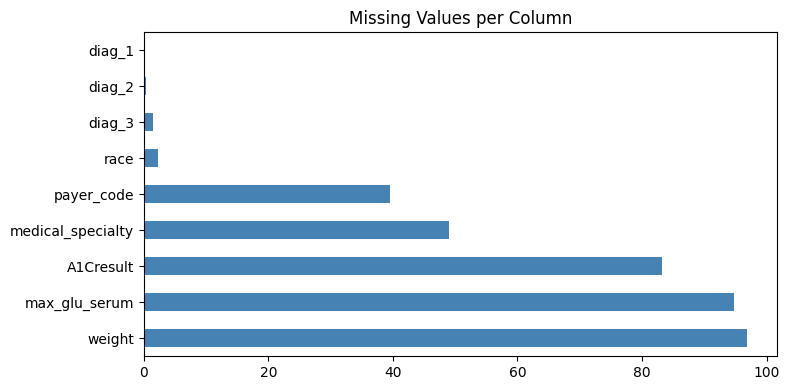

In [3]:
df_temp = df.replace("?", np.nan)
missing = df_temp.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
miss_df = pd.DataFrame({"Missing Count": missing, "Missing %": (missing/len(df)*100).round(2)})
print(miss_df.to_string())
fig, ax = plt.subplots(figsize=(8, 4))
miss_df["Missing %"].plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Missing Values per Column"); plt.tight_layout(); plt.show()

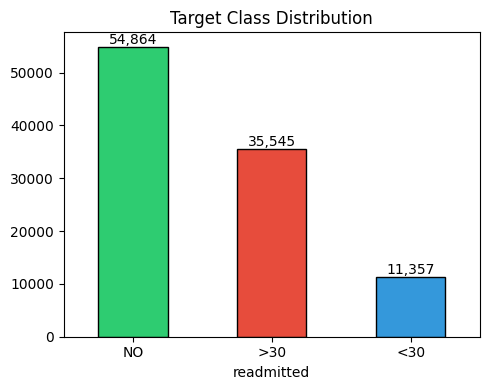

In [4]:
target_counts = df["readmitted"].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind="bar", ax=ax, color=["#2ecc71","#e74c3c","#3498db"], edgecolor="black")
ax.set_title("Target Class Distribution"); ax.set_xticklabels(target_counts.index, rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout(); plt.show()

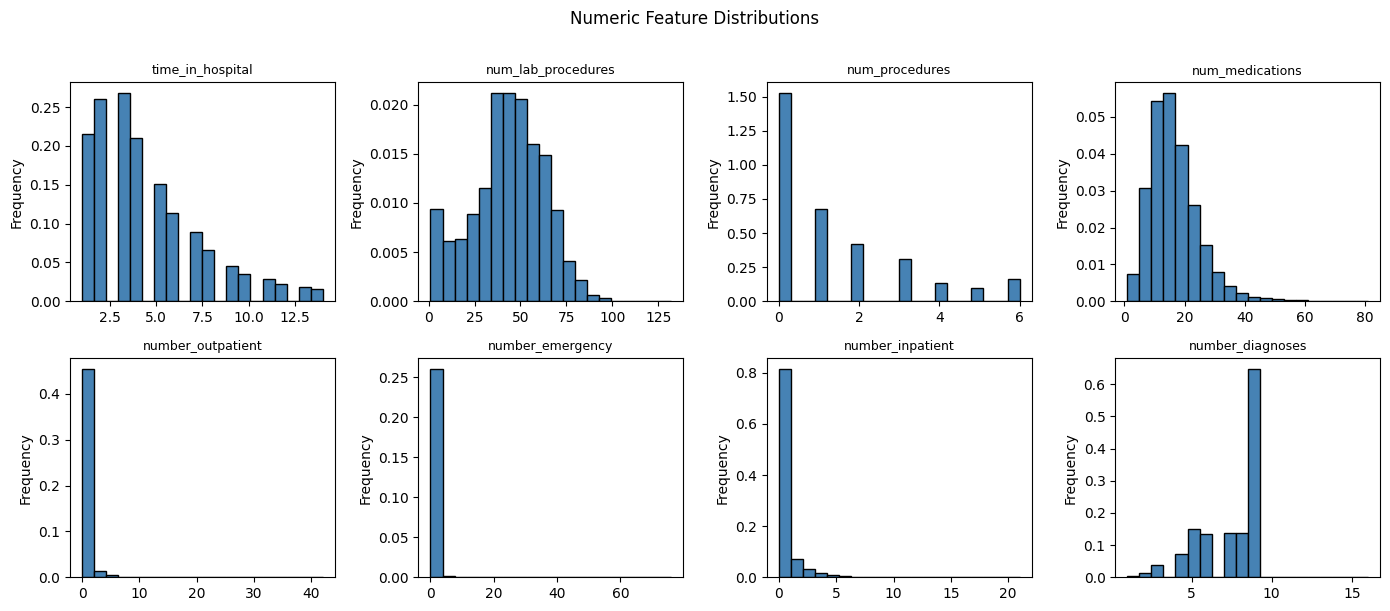

In [5]:
num_cols = ["time_in_hospital","num_lab_procedures","num_procedures","num_medications",
            "number_outpatient","number_emergency","number_inpatient","number_diagnoses"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.flat, num_cols):
    df[col].plot(kind="hist", bins=20, ax=ax, color="steelblue", edgecolor="black", density=True)
    ax.set_title(col, fontsize=9)
plt.suptitle("Numeric Feature Distributions", y=1.01); plt.tight_layout(); plt.show()

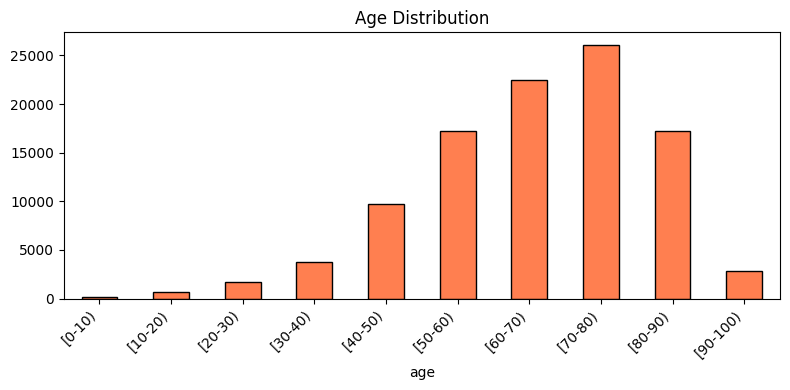

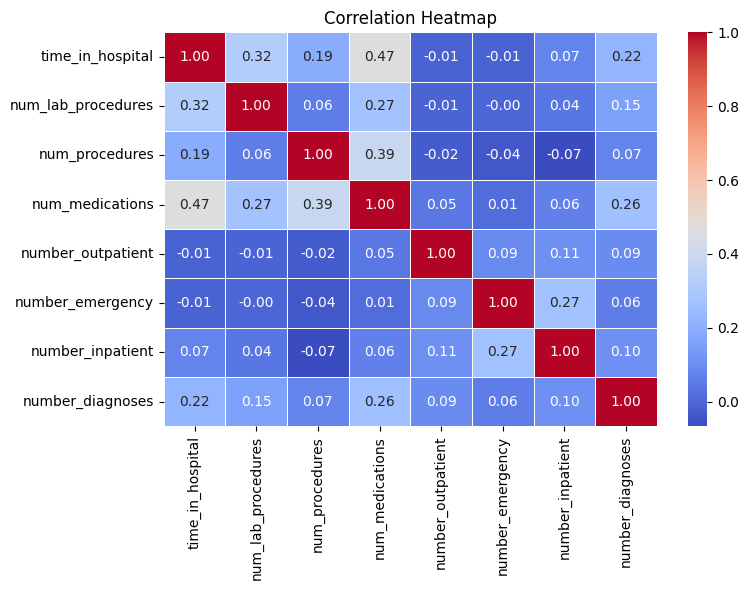

In [6]:
age_order = ["[0-10)","[10-20)","[20-30)","[30-40)","[40-50)","[50-60)","[60-70)","[70-80)","[80-90)","[90-100)"]
fig, ax = plt.subplots(figsize=(8, 4))
df["age"].value_counts().reindex(age_order).plot(kind="bar", ax=ax, color="coral", edgecolor="black")
ax.set_title("Age Distribution"); ax.set_xticklabels(age_order, rotation=45, ha="right")
plt.tight_layout(); plt.show()

corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap"); plt.tight_layout(); plt.show()

In [7]:
# Drop columns
cols_to_drop = ["encounter_id","patient_nbr","change","diabetesMed","num_medications","weight","payer_code"]
data = df.drop(columns=cols_to_drop, errors="ignore").copy()

# Target encoding Binary — 0 = Not Readmitted, 1 = Readmitted (<30 or >30)
data["readmitted"] = data["readmitted"].map({"NO": 0, "<30": 1, ">30": 1})
data = data.dropna(subset=["readmitted"]).reset_index(drop=True)
data["readmitted"] = data["readmitted"].astype(np.int8)
print("Target distribution after encoding:")
print(data["readmitted"].value_counts())
# Expected: 0 → ~54864,  1 → ~46902

# Replace ?
data.replace("?", np.nan, inplace=True)

# Gender
data["gender"] = data["gender"].map({"Male":1,"Female":0})
data["gender"] = data["gender"].fillna(data["gender"].mode()[0]).astype(np.int8)

# Age ordinal
age_map = {"[0-10)":0,"[10-20)":1,"[20-30)":2,"[30-40)":3,"[40-50)":4,
           "[50-60)":5,"[60-70)":6,"[70-80)":7,"[80-90)":8,"[90-100)":9}
data["age"] = data["age"].map(age_map).astype(np.int8)

# Admission IDs
data["admission_type_id"] = data["admission_type_id"].map(
    {1:"Emergency",2:"Urgent",3:"Elective",4:"Newborn",5:"Not_Available",6:"NULL",7:"Trauma_Center",8:"Not_Mapped"}).fillna("Unknown")
data["discharge_disposition_id"] = data["discharge_disposition_id"].map(
    {1:"Discharged_Home",2:"Discharged_Short_Term",3:"Skilled_Nursing",6:"Home_Health",
     7:"AMA",11:"Expired",13:"Hospice_Medical",14:"Hospice_Home",18:"Not_Mapped",25:"Not_Mapped_25"}).fillna("Unknown")
data["admission_source_id"] = data["admission_source_id"].map(
    {1:"Physician_Referral",2:"Clinic_Referral",3:"HMO_Referral",4:"Transfer_Hospital",
     7:"Emergency_Room",9:"Not_Available",11:"Normal_Delivery",17:"NULL",20:"Unknown"}).fillna("Unknown")
print("Admission recoded ✓")

Target distribution after encoding:
readmitted
0    54864
1    46902
Name: count, dtype: int64
Admission recoded ✓


In [8]:
def group_diag(val):
    if pd.isna(val) or val == "Missing": return "Other"
    val = str(val).strip()
    if val.startswith("V") or val.startswith("E"): return "External"
    try: code = float(val)
    except ValueError: return "Other"
    if 390 <= code <= 459 or code == 785: return "Circulatory"
    elif 460 <= code <= 519 or code == 786: return "Respiratory"
    elif 520 <= code <= 579 or code == 787: return "Digestive"
    elif 250 <= code <= 250.99: return "Diabetes"
    elif 800 <= code <= 999: return "Injury"
    elif 710 <= code <= 739: return "Musculoskeletal"
    elif 580 <= code <= 629 or code == 788: return "Genitourinary"
    elif 140 <= code <= 239: return "Neoplasms"
    else: return "Other"

for col in ["diag_1","diag_2","diag_3"]:
    data[col] = data[col].apply(group_diag)

data["max_glu_serum"] = data["max_glu_serum"].fillna("None")
data["A1Cresult"]     = data["A1Cresult"].fillna("None")
data["medical_specialty"] = data["medical_specialty"].fillna("Missing")
data["race"]              = data["race"].fillna("Missing")

cat_cols = data.select_dtypes(include="object").columns.tolist()
data = pd.get_dummies(data, columns=cat_cols, drop_first=False, dtype=np.int8)
print(f"Shape after encoding: {data.shape}")

Shape after encoding: (101766, 226)


In [9]:
X = data.drop("readmitted", axis=1)
y = data["readmitted"]
for col in X.select_dtypes(include=["int64","float64"]).columns:
    X[col] = pd.to_numeric(X[col], downcast="integer")
print(f"Memory: {round(X.memory_usage(deep=True).sum()/1e6,2)} MB")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")

Memory: 23.0 MB
Train: (81412, 225) | Test: (20354, 225)


In [10]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_te, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_te, y_pred, average="weighted", zero_division=0)
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print(f"  Accuracy : {acc:.4f}\n  Precision: {prec:.4f}\n  Recall   : {rec:.4f}\n  F1-Score : {f1:.4f}")
    print(classification_report(y_te, y_pred, target_names=["Not Readmitted", "Readmitted"]))
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Not Readmitted", "Readmitted"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name}"); plt.tight_layout(); plt.show()
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
    return model

print("Helper ready ✓")

Helper ready ✓



  Random Forest
  Accuracy : 0.6413
  Precision: 0.6406
  Recall   : 0.6413
  F1-Score : 0.6408
                precision    recall  f1-score   support

Not Readmitted       0.66      0.68      0.67     10973
    Readmitted       0.61      0.59      0.60      9381

      accuracy                           0.64     20354
     macro avg       0.64      0.64      0.64     20354
  weighted avg       0.64      0.64      0.64     20354



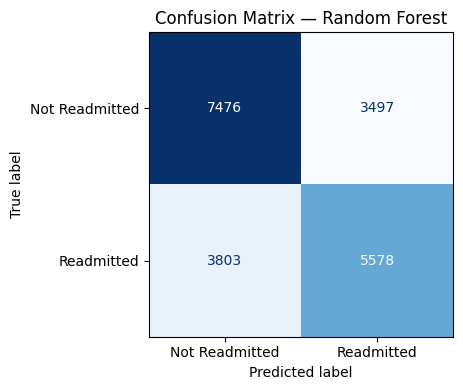

In [11]:
rf = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=5,
                             n_jobs=-1, random_state=42, class_weight="balanced")
rf = evaluate_model("Random Forest", rf, X_train_sc, y_train, X_test_sc, y_test)


  Gradient Boosting
  Accuracy : 0.6441
  Precision: 0.6437
  Recall   : 0.6441
  F1-Score : 0.6386
                precision    recall  f1-score   support

Not Readmitted       0.65      0.75      0.70     10973
    Readmitted       0.64      0.52      0.57      9381

      accuracy                           0.64     20354
     macro avg       0.64      0.63      0.63     20354
  weighted avg       0.64      0.64      0.64     20354



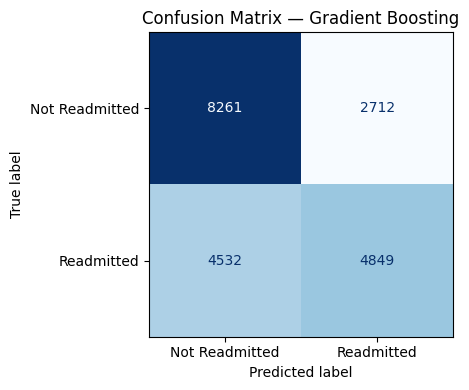

In [12]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                 max_depth=5, subsample=0.8, random_state=42)
gb = evaluate_model("Gradient Boosting", gb, X_train_sc, y_train, X_test_sc, y_test)


  AdaBoost
  Accuracy : 0.6338
  Precision: 0.6348
  Recall   : 0.6338
  F1-Score : 0.6246
                precision    recall  f1-score   support

Not Readmitted       0.63      0.77      0.69     10973
    Readmitted       0.64      0.47      0.54      9381

      accuracy                           0.63     20354
     macro avg       0.64      0.62      0.62     20354
  weighted avg       0.63      0.63      0.62     20354



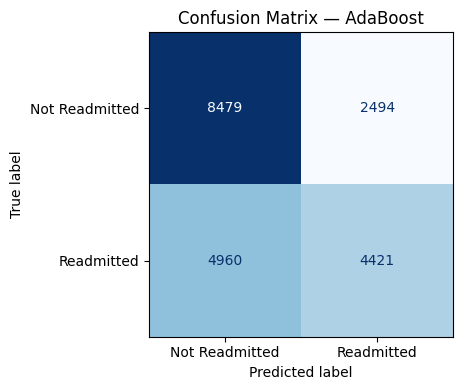

In [13]:
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                          n_estimators=100, learning_rate=0.5, random_state=42, algorithm="SAMME")
ada = evaluate_model("AdaBoost", ada, X_train_sc, y_train, X_test_sc, y_test)


  Voting Classifier (Hard)
  Accuracy : 0.6424
  Precision: 0.6414
  Recall   : 0.6424
  F1-Score : 0.6381
                precision    recall  f1-score   support

Not Readmitted       0.65      0.74      0.69     10973
    Readmitted       0.63      0.53      0.58      9381

      accuracy                           0.64     20354
     macro avg       0.64      0.63      0.63     20354
  weighted avg       0.64      0.64      0.64     20354



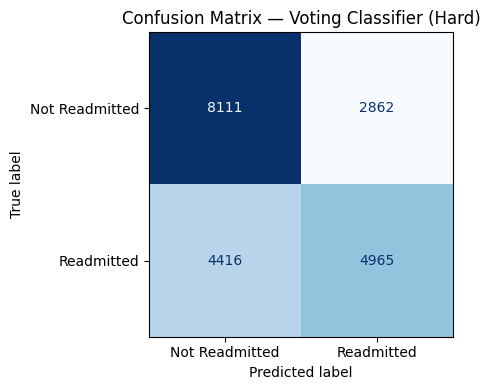


  Voting Classifier (Soft)
  Accuracy : 0.6429
  Precision: 0.6423
  Recall   : 0.6429
  F1-Score : 0.6377
                precision    recall  f1-score   support

Not Readmitted       0.65      0.75      0.69     10973
    Readmitted       0.64      0.52      0.57      9381

      accuracy                           0.64     20354
     macro avg       0.64      0.63      0.63     20354
  weighted avg       0.64      0.64      0.64     20354



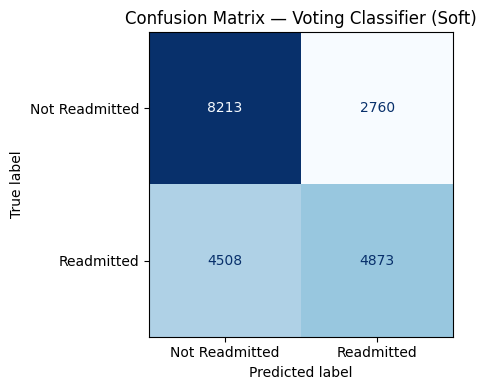

In [14]:
voting_hard = VotingClassifier(estimators=[("rf",rf),("gb",gb),("ada",ada)], voting="hard", n_jobs=-1)
voting_hard = evaluate_model("Voting Classifier (Hard)", voting_hard, X_train_sc, y_train, X_test_sc, y_test)

voting_soft = VotingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=42, class_weight="balanced")),
        ("gb",  GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, subsample=0.8, random_state=42)),
        ("ada", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100, learning_rate=0.5, random_state=42, algorithm="SAMME"))
    ], voting="soft", n_jobs=-1)
voting_soft = evaluate_model("Voting Classifier (Soft)", voting_soft, X_train_sc, y_train, X_test_sc, y_test)


  Stacking Classifier
  Accuracy : 0.6456
  Precision: 0.6446
  Recall   : 0.6456
  F1-Score : 0.6418
                precision    recall  f1-score   support

Not Readmitted       0.65      0.74      0.69     10973
    Readmitted       0.64      0.54      0.58      9381

      accuracy                           0.65     20354
     macro avg       0.64      0.64      0.64     20354
  weighted avg       0.64      0.65      0.64     20354



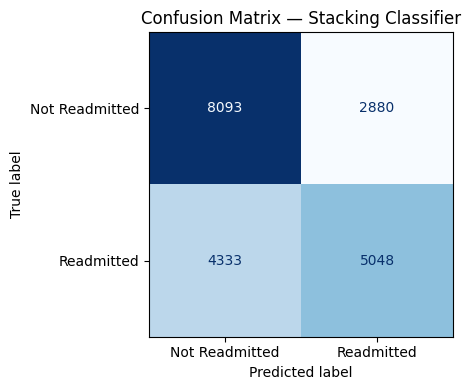

In [15]:
stacking = StackingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=42, class_weight="balanced")),
        ("gb",  GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, subsample=0.8, random_state=42)),
        ("ada", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=100, learning_rate=0.5, random_state=42, algorithm="SAMME")),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3, n_jobs=-1)
stacking = evaluate_model("Stacking Classifier", stacking, X_train_sc, y_train, X_test_sc, y_test)

                          Accuracy  Precision  Recall  F1-Score
Stacking Classifier         0.6456     0.6446  0.6456    0.6418
Random Forest               0.6413     0.6406  0.6413    0.6408
Gradient Boosting           0.6441     0.6437  0.6441    0.6386
Voting Classifier (Hard)    0.6424     0.6414  0.6424    0.6381
Voting Classifier (Soft)    0.6429     0.6423  0.6429    0.6377
AdaBoost                    0.6338     0.6348  0.6338    0.6246


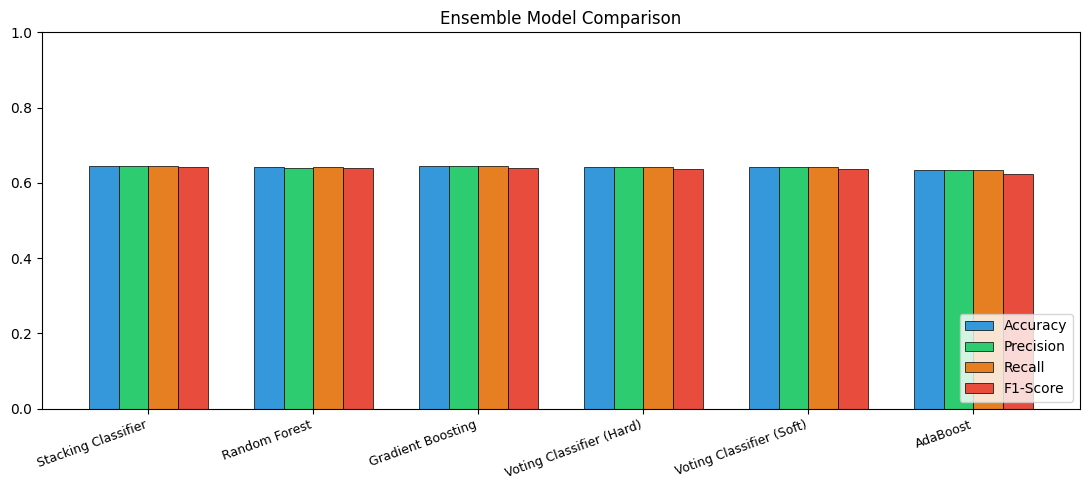


✅ Best Model: Stacking Classifier
Accuracy     0.6456
Precision    0.6446
Recall       0.6456
F1-Score     0.6418
Name: Stacking Classifier, dtype: float64


In [16]:
comp_df = pd.DataFrame(results).T.sort_values("F1-Score", ascending=False).round(4)
print(comp_df.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comp_df))
for i, (metric, color) in enumerate(zip(["Accuracy","Precision","Recall","F1-Score"],
                                          ["#3498db","#2ecc71","#e67e22","#e74c3c"])):
    ax.bar(x + i*0.18, comp_df[metric], 0.18, label=metric, color=color, edgecolor="black", linewidth=0.5)
ax.set_xticks(x + 0.27); ax.set_xticklabels(comp_df.index, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0,1.0); ax.set_title("Ensemble Model Comparison"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

best = comp_df["F1-Score"].idxmax()
print(f"\n✅ Best Model: {best}")
print(comp_df.loc[best])